In [14]:
import numpy as np
import random
import matplotlib.pyplot as plt

states = np.array([0,1])
actions = np.array([0,1]) #0 = stay, #1 = move
N = 100000 #number of steps
phi = 500 #soft-min parameter
p = 0.1
c_g = 5
c_l = 5
gamma = 0.5
om_q = 0.55
om_mu = 0.75
om_mu_global = 0.95
jump = round(N / 100) # take a measurement of mu every "jump" step
num_X = len(states)
num_A = len(actions)

Q = np.zeros([num_X, num_A], dtype=float)
mu_local = np.ones([num_X, num_A, num_X], dtype=float)
print(mu_local)
 # separate mean field for each trajectory
mu_local = mu_local / num_X
mu_global = np.zeros((N+1, num_X))
mu_global[0] = np.ones(num_X) / num_X

def rhosCalc(count_xaxa, count_xa):
    rhoQ = 1 / np.pow(1 + count_xa, om_q)
    rhoMu = 1 / np.pow(1 + count_xaxa, om_mu)
    rhoMuGlobal = 1 / np.pow(1 + count_xaxa, om_mu_global)
    return {
        'q': rhoQ,
        'mu': rhoMu,
        'mu_global': rhoMuGlobal
    }

def env(state, action, mu_local, mu_global):
    newS = state
    if random.random() > p:
        newS = (state + action) % 2
    else:
        newS = (state + action - 1) % 2
    return {
        "newState": newS,
        "cost": state + c_g * mu_local[0] + c_l * mu_global[0]
    }

def pi_xa_policy(Q_xa_state, x, a, state):
    if state == x:
        return a
    else:
        return stable_softmin_action(Q_xa_state, actions)[0]

def stable_softmin_action(q_values, actions, phi=phi):
    scaled_q = -phi * np.array(q_values)
    z = scaled_q - np.max(scaled_q)
    numerator = np.exp(z)
    denominator = np.sum(numerator)
    probabilities = numerator / denominator
    
    if np.isnan(probabilities).any():
        print("Warning: NaNs still present in probabilities. Check input Q_values or phi value.")
        return np.random.choice(actions), probabilities
    
    return np.random.choice(actions, p=probabilities), probabilities

# Initialize tracking structures
abridgedmu = []
abridged_mu_global = []
state = []

# Add main trajectory state
main_state = np.random.choice(states, p=mu_global[0])

for x in range(num_X):
    abridgedmu.append([])
    state.append([])
    for a in range(num_A):
        abridgedmu[x].append([])
        state[x].append(np.random.choice(states, p=mu_local[x][a]))

# Counters for rho calculation
countMu = np.zeros([num_X, num_A, num_X, num_A], dtype=int)
countQ = np.zeros([num_X, num_A], dtype=int)

# Main simulation loop
for n in range(N):
    rho_mu_global = 1 / np.power(1 + n, om_mu_global)
    
    
    main_action = stable_softmin_action(Q[main_state], actions)[0]
    
    #Get next state and cost for main trajectory
    main_envir = env(main_state, main_action, mu_local[main_state][main_action], mu_global[n])
    
    #  Update auxiliary trajectories
    for x in range(num_X):
        for a in range(num_A):
            # Choose action according to pi_(x,a) policy
            action = pi_xa_policy(Q[state[x][a]], x, a, state[x][a])
            
            # Update counters
            countMu[x][a][state[x][a]][action] += 1
            if state[x][a] == x and action == a:
                # This auxiliary trajectory is at its "designated" state-action pair
                countQ[x][a] += 1
            
            rhos = rhosCalc(countMu[x][a][state[x][a]][action], countQ[x][a])
            
            # Get next state and cost for auxiliary trajectory
            envir = env(state[x][a], action, mu_local[x][a], mu_global[n])
            
            # Step 7: Update local mean field
            delta_X_n = np.zeros(num_X)
            delta_X_n[envir["newState"]] += 1
            mu_local[x][a] = mu_local[x][a] + rhos['mu'] * (delta_X_n - mu_local[x][a])
            
            # Step 9-10: Update Q when auxiliary trajectory state matches main trajectory state
            if state[x][a] == main_state:
                # The auxiliary trajectory X_n^(x,a) matches main trajectory X_n
                # So we update Q(x,a) - but only if this is the "designated" state for (x,a)
                if state[x][a] == x and action == a:
                    Q[x][a] = Q[x][a] + rhos['q'] * (
                        envir["cost"] + gamma * np.min(Q[envir["newState"]]) - Q[x][a]
                    )
            
            # Update auxiliary state
            state[x][a] = envir["newState"]
            
            if n % jump == 0:
                abridgedmu[x][a].append(mu_local[x][a][0])
    
    #Update global distribution from main trajectory ONLY
    delta_X_main = np.zeros(num_X)
    delta_X_main[main_envir["newState"]] = 1
    mu_global[n+1] = mu_global[n] + rho_mu_global * (delta_X_main - mu_global[n])
    
    # Update main state
    main_state = main_envir["newState"]
    
    if n % jump == 0:
        abridged_mu_global.append(mu_global[n, 0])

# Final append
for x in range(num_X):
    for a in range(num_A):
        abridgedmu[x][a].append(mu_local[x][a][0])
abridged_mu_global.append(mu_global[N, 0])



[[[1. 1.]
  [1. 1.]]

 [[1. 1.]
  [1. 1.]]]


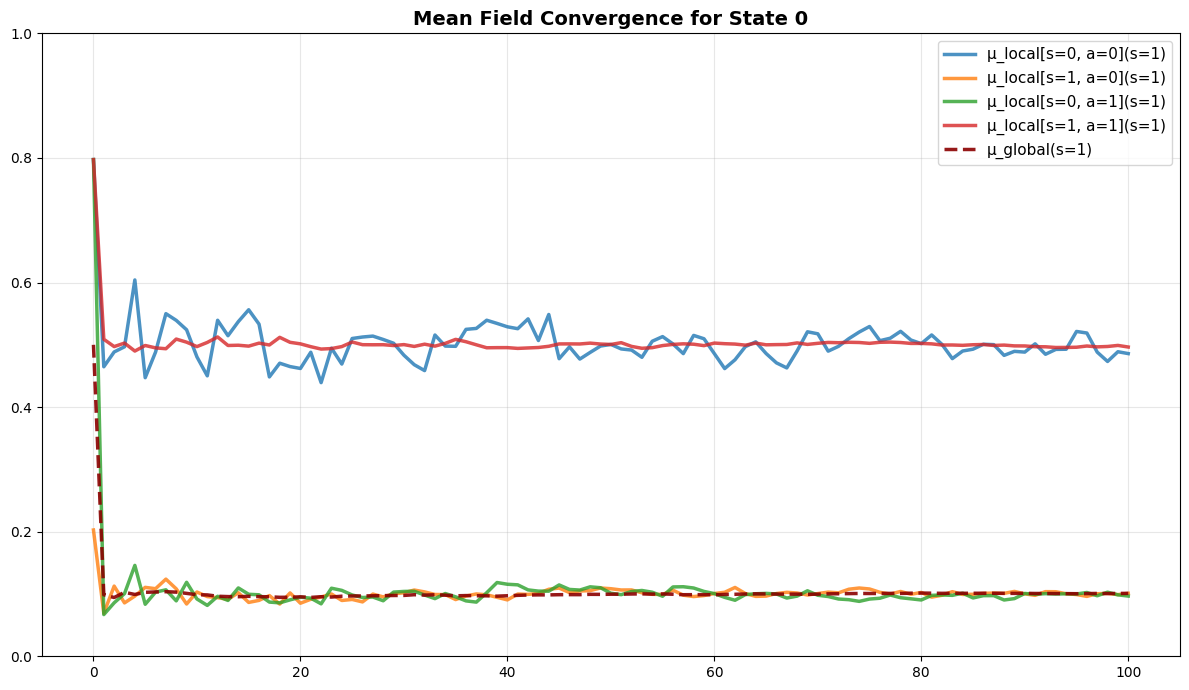

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Create single figure
plt.figure(figsize=(12, 7))

# Plot local mu for x=0, both actions

for a in range(num_A):
    for s in range(num_X):
        label = f'μ_local[s={s}, a={a}](s=1)'
        plt.plot(abridgedmu[s][a], label=label, alpha=0.8, linewidth=2.5)

# Plot global mu
plt.plot(abridged_mu_global, color='darkred', linewidth=2.5, 
         label='μ_global(s=1)', linestyle='--', alpha=0.9)



plt.title('Mean Field Convergence for State 0', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

In [16]:
print(Q)
print('----------------')
print(mu_local[-1])
print('----------------')
print(mu_global[-1])


[[4.47552435 2.89557075]
 [3.89826449 5.49147345]]
----------------
[[0.10107271 0.89892729]
 [0.49644404 0.50355596]]
----------------
[0.10098305 0.89901695]
